In [1]:
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot summary

In [2]:
df = pd.read_csv("results/NASCseq_Summary.csv")
df = df[df["Run"].isin(["20220113_NASCseq", "20220321_NASCseq", "20220418_NASCseq"])]

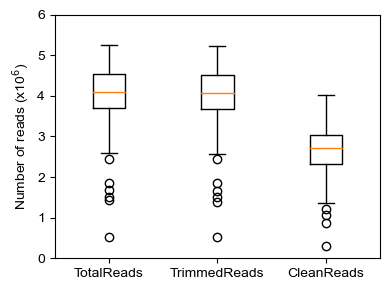

In [3]:
plt.figure(figsize=(4, 3))
plt.boxplot(df[["Total.Reads", "Trimmed.Reads", "Clean.Reads"]]/1e6, showmeans=False)
xs = np.arange(3) + 1
plt.xticks(xs, ["TotalReads", "TrimmedReads", "CleanReads"])
plt.ylabel("Number of reads (x10$^6$)")
plt.ylim(0, 6)
plt.tight_layout()
plt.savefig("figures/reads_number.pdf")

In [4]:
vs = df["Total.Reads"]
print("Total reads:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Trimmed.Reads"]
print("Trimmed reads:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Clean.Reads"]
print("Clean reads:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Trimmed.Reads"]/ df["Total.Reads"]
print("Trimmed ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Clean.Reads"]/ df["Trimmed.Reads"]
print("Clean ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = 1 - df["Clean.Reads"]/ df["Trimmed.Reads"]
print("rRNA ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

Total reads:
Mean: 4031457.2937062937
Std: 745910.7776131205
Trimmed reads:
Mean: 4003310.923076923
Std: 741806.8204065149
Clean reads:
Mean: 2633320.5314685316
Std: 650494.3220101877
Trimmed ratios:
Mean: 0.9928423783157385
Std: 0.002603650476566177
Clean ratios:
Mean: 0.6613211831185072
Std: 0.12453558557902278
rRNA ratios:
Mean: 0.3386788168814929
Std: 0.12453558557902278


In [5]:
vs = df["UniqMapped.Ratio"]
print("Uniquely mapped ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

Uniquely mapped ratios:
Mean: 0.7239023465286464
Std: 0.07463624851844067


In [6]:
vs = df["Stranded.Ratio"]
print("Stranded ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

Stranded ratios:
Mean: 0.9314307777265985
Std: 0.04755638875795311


# Plot comparison

In [19]:
info = pd.read_csv("results/NASCseq_Summary.csv")
data = dict()
for name in ["GSE128273_NASCseq", "NASCseq"]:
    if name == "GSE128273_NASCseq":
        info1 = info[[run.startswith("GSE") for run in info["Run"]]]
    else:
        info1 = info[[run.startswith("20") for run in info["Run"]]]
    for s4u, d1 in info1.groupby(by="s4U"):
        for time, d2 in d1.groupby(by="Time"):
            data["%s.s4U_%duM_%s" % (name, s4u, ("%dmin" % (time * 60)) if time < 1 else ("%dh" % time))] = d2

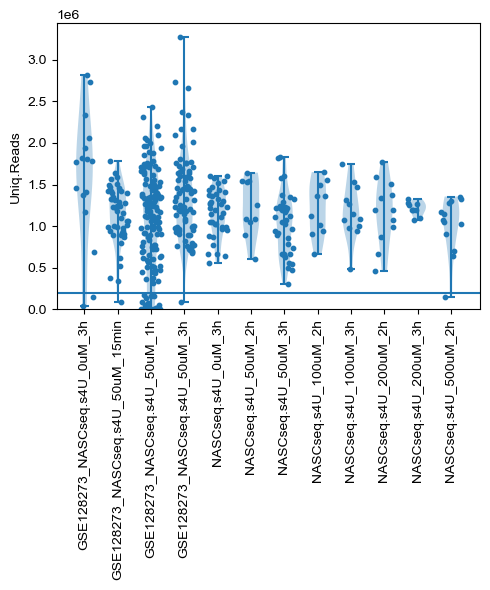

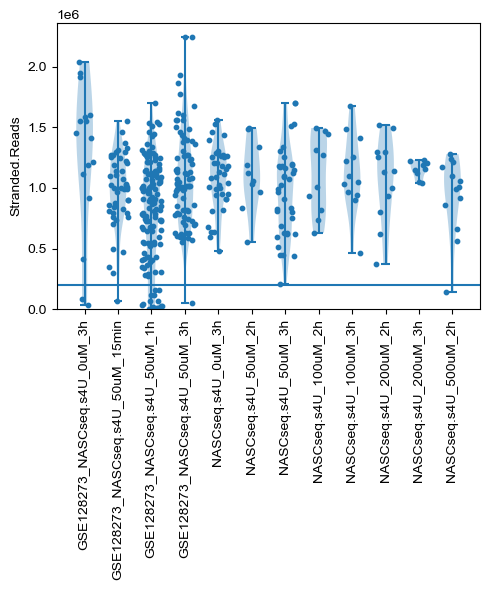

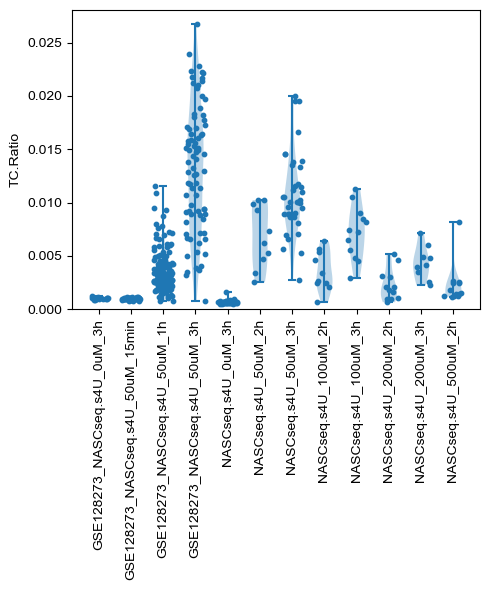

In [20]:
np.random.seed(0)
for k in ["Uniq.Reads", "Stranded.Reads", "TC.Ratio"]:
    xs = np.arange(len(data))
    vs = [d[k] for d in data.values()]
    plt.figure(figsize=(5, 6))
    plt.violinplot(vs, positions=xs)
    for x, ys in zip(xs, vs):
        for y in ys:
            x1 = x + (np.random.random() - 0.5) * 0.6
            plt.scatter(x1, y, marker="o", s=10, color="C0")
    if "Reads" in k:
        plt.axhline(200000)
    plt.xticks(xs, data.keys(), rotation=90)
    plt.ylim(0, None)
    plt.ylabel(k)
    plt.tight_layout()
    plt.show()

In [22]:
for name, d in data.items():
    n1, n2, n3 = len(d), sum(d["Uniq.Reads"] >= 200000), sum(d["Stranded.Reads"] >= 200000)
    print(n1, n2, "%.4f" % (n2/n1), n3, "%.4f" % (n3/n1), name, sep="\t")

16	14	0.8750	14	0.8750	GSE128273_NASCseq.s4U_0uM_3h
46	45	0.9783	45	0.9783	GSE128273_NASCseq.s4U_50uM_15min
142	122	0.8592	122	0.8592	GSE128273_NASCseq.s4U_50uM_1h
80	79	0.9875	79	0.9875	GSE128273_NASCseq.s4U_50uM_3h
39	39	1.0000	39	1.0000	NASCseq.s4U_0uM_3h
10	10	1.0000	10	1.0000	NASCseq.s4U_50uM_2h
38	38	1.0000	38	1.0000	NASCseq.s4U_50uM_3h
10	10	1.0000	10	1.0000	NASCseq.s4U_100uM_2h
12	12	1.0000	12	1.0000	NASCseq.s4U_100uM_3h
12	12	1.0000	12	1.0000	NASCseq.s4U_200uM_2h
9	9	1.0000	9	1.0000	NASCseq.s4U_200uM_3h
13	12	0.9231	12	0.9231	NASCseq.s4U_500uM_2h


# Percentage of recovered reads

In [10]:
info = pd.read_csv("results/NASCseq_Summary.csv")
info = info[info["Stranded.Reads"] >= 200000]
print(info.shape)

columns = ["Total.Reads", "Trimmed.Reads", "Clean.Reads", "UniqMapped.Reads", "Filtered.Reads", "Uniq.Reads", "Stranded.Reads"]
ticks = ["Total", "Trimmed", "Clean", "Mapped", "Filtered", "RmDup", "Stranded"]
colors = ["C0", "C7", "C7", "C7", "C7", "C7", "C2"]

for i, c in enumerate(columns):
    vs = info[c] * 100 / info["Total.Reads"]
    print(ticks[i], np.mean(vs), np.std(vs), sep="\t")

(402, 44)
Total	100.0	0.0
Trimmed	97.68950781240348	1.702154169756572
Clean	67.578083345215	11.92063299341307
Mapped	51.07101110041169	14.801179493687414
Filtered	45.64287959865417	14.3264668380303
RmDup	36.88826419912656	15.61931415317838
Stranded	30.366161577793118	11.18197192614099


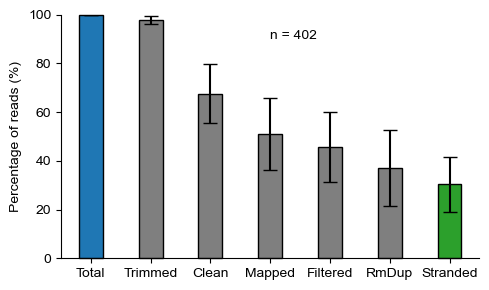

In [11]:
plt.figure(figsize=(5, 3))
for i, c in enumerate(columns):
    vs = info[c] * 100 / info["Total.Reads"]
    plt.bar(i, np.mean(vs), yerr=np.std(vs), width=0.4, capsize=5, color=colors[i], edgecolor="black", lw=1, clip_on=False)
plt.xlim(-0.5, len(columns) - 0.5)
plt.ylim(0, 100)
plt.text(3, 90, "n = %d" % info.shape[0])
plt.xticks(np.arange(len(ticks)), ticks)
plt.ylabel("Percentage of reads (%)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/percentage_of_reads.pdf")

(402, 44)
Forward	43.03237668301291	4.9595481522318705
Reverse	41.30834856658776	5.132380643928265
Ambiguous	3.388104539253387	0.7403567394247699
Unknown	12.27117021114595	9.425323566953795


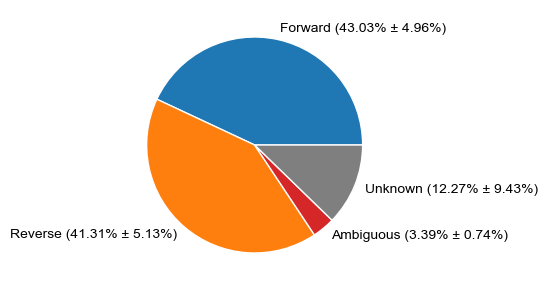

In [12]:
info = pd.read_csv("results/NASCseq_Summary.csv")
info = info[info["Stranded.Reads"] >= 200000]
print(info.shape)

array = []
for cell in info["Cell"]:
    array.append(pd.read_csv("../../results/1_nascseq/2_bams/markstrand/%s/%s.tsv" % (cell.split(".")[0], cell), sep="\t", index_col=0))
m = pd.concat(array)
m = m.divide(m.sum(axis=1), axis=0) * 100

means = m.mean(axis=0)
stds = m.std(axis=0)
names = ["Forward", "Reverse", "Ambiguous", "Unknown"]
labels = []
for name, mean, std in zip(names, means, stds):
    print(name, mean, std, sep="\t")
    labels.append("%s (%.2f%% ± %.2f%%)" % (name, mean, std))
colors = ["C0", "C1", "C3", "C7"]

plt.figure(figsize=(6, 3))
plt.pie(means, labels=labels, wedgeprops=dict(edgecolor="white"), colors=colors)
plt.tight_layout()
plt.savefig("figures/pie_of_stranded_reads.pdf")

(427, 44)
Median of GSE128273_NASCseq: 0.99429
Median of NASCseq: 1.089715


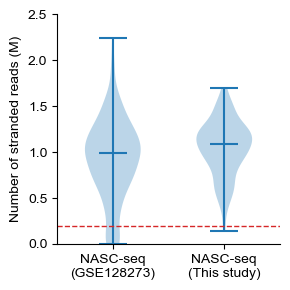

In [13]:
info = pd.read_csv("results/NASCseq_Summary.csv")
print(info.shape)
vs1 = info[[not cell.startswith("20") for cell in info["Cell"]]]["Stranded.Reads"]/1e6
vs2 = info[[cell.startswith("20") for cell in info["Cell"]]]["Stranded.Reads"]/1e6
print("Median of GSE128273_NASCseq:", np.median(vs1))
print("Median of NASCseq:", np.median(vs2))

plt.figure(figsize=(3, 3))
plt.violinplot([vs1, vs2], showmedians=True)
plt.axhline(0.2, lw=1, ls="--", color="C3")
plt.xlim(0.5, 2.5)
plt.ylim(0, 2.5)
plt.xticks([1, 2], ["NASC-seq\n(GSE128273)", "NASC-seq\n(This study)"])
plt.ylabel("Number of stranded reads (M)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/number_of_stranded_reads.pdf")